## Detecting outliers and adapting models to these

In [ ]:
import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

from pinard import utils
from pinard import preprocessing as pp
from pinard.model_selection import train_test_split_idx

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
simplefilter(action='ignore', category=UserWarning)

### Importation of the datasets

In [2]:
# Function to load a CSV file with automatic separator detection

def load_csv_auto_sep(path):
    with open(path, 'r', newline='', encoding='utf-8') as f:
        # Read a small portion of the file to detect the separator
        excerpt = f.read(1024)
        f.seek(0)  # return to the beginning of the file

        # Detection of the dialect
        dialect = csv.Sniffer().sniff(excerpt)
        sep = dialect.delimiter

        print("Detected separator : %s" % sep)
        
        # Load the file with pandas
        df = pd.read_csv(f, delimiter=sep)
        return df

In [27]:
mode = 'Regression' # 'Classification' or 'Regression'
 
## Choose the source of data to be imported
# Regression: 'BeerOriginalExtract' or 'Digest_0.8' or 'YamProtein' //
# Classification: 'CoffeeSpecies' or 'Malaria2024' or 'mDigest_custom3' or 'WhiskyConcentration' or 'YamMould'
data_source = 'YamProtein'

## Importation of the datasets with the adapted path
file_name = Path("Data/%s/%s"% (mode,data_source))
full_path = str(file_name.resolve()).replace("\\", "/")

Xcal = load_csv_auto_sep(f'{full_path}/Xcal.csv')
Xval = load_csv_auto_sep(f'{full_path}/Xval.csv')
Ycal = load_csv_auto_sep(f'{full_path}/Ycal.csv')
Yval = load_csv_auto_sep(f'{full_path}/Yval.csv')

print("Number of spectra for calibration: ", len(Ycal))
print("Number of spectra for test: ", len(Yval))
display(Xcal.head(5))

Detected separator : ;
Detected separator : ;
Detected separator : 
Detected separator : 
Number of spectra for calibration:  784
Number of spectra for test:  248


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V1041,V1042,V1043,V1044,V1045,V1046,V1047,V1048,V1049,V1050
0,0.163048,0.168517,0.173601,0.178055,0.181673,0.184674,0.187279,0.189404,0.190971,0.192225,...,0.728563,0.730664,0.732373,0.733608,0.734403,0.734922,0.735155,0.735095,0.734736,0.734165
1,0.159370,0.164547,0.169495,0.173999,0.177437,0.180028,0.182533,0.184882,0.186467,0.187515,...,0.720091,0.722194,0.723811,0.725038,0.725865,0.726412,0.726530,0.726389,0.726011,0.725416
2,0.163048,0.168517,0.173601,0.178055,0.181673,0.184674,0.187279,0.189404,0.190971,0.192225,...,0.728563,0.730664,0.732373,0.733608,0.734403,0.734922,0.735155,0.735095,0.734736,0.734165
3,0.159370,0.164547,0.169495,0.173999,0.177437,0.180028,0.182533,0.184882,0.186467,0.187515,...,0.720091,0.722194,0.723811,0.725038,0.725865,0.726412,0.726530,0.726389,0.726011,0.725416
4,0.148814,0.153634,0.157951,0.161528,0.164204,0.166344,0.168472,0.170332,0.171494,0.172274,...,0.717764,0.719747,0.721370,0.722661,0.723523,0.724061,0.724311,0.724114,0.723626,0.723033


### Construction of the pipelines

In [28]:
rd_seed = 42
rd_seed = np.random.seed(rd_seed)

x, y = pd.concat([Xcal,Xval], axis=0).values, pd.concat([Ycal,Yval], axis=0).values

### Declare preprocessing methods that will be used
preprocessing = [   ('id', pp.IdentityTransformer()),
                    ('baseline', pp.Baseline()),
                    ('derivate', pp.Derivate()),
                    ('detrend', pp.Detrend()),
                    ('MSC', pp.MultiplicativeScatterCorrection()),
                    ('normalize', pp.Normalize()),
                    ('RNV', pp.RobustNormalVariate()),
                    ('savgol', pp.SavitzkyGolay()),
                    ('simplescale', pp.SimpleScale()),
                    ('SNV', pp.StandardNormalVariate()),
                    ('haar', pp.Wavelet('haar')),
                    ('gaussian', pp.Gaussian(order = 2, sigma = 1)),
                    ('PCA', PCA())
                ]

# Apply the preprocessing methods to the calibration dataset
transformed_datasets = {}
for name, method in preprocessing:
    x = method.fit_transform(Xcal)
    transformed_datasets[name] = x

### Detection of outliers with PCA

In [30]:
scaler = StandardScaler(with_std=False)
dict_outliers = {}
for name, method in preprocessing:
    x = transformed_datasets[name]
    X_scaled = scaler.fit_transform(x)

    # Perform PCA on the scaled data
    X_pca = PCA(n_components=1).fit_transform(X_scaled)

    # Store the PCA scores in a DataFrame for easier manipulation
    scores_df = pd.DataFrame(X_pca, columns=['PC1'])

    # Compute the bounds for extreme individuals
    mean_PC1 = scores_df['PC1'].mean()
    std_PC1 = scores_df['PC1'].std()
    lower_bound = mean_PC1 - 2 * std_PC1
    upper_bound = mean_PC1 + 2 * std_PC1

    # Filter the extreme individuals based on the bounds
    extreme_individuals = scores_df[
        (scores_df['PC1'] < lower_bound) | (scores_df['PC1'] > upper_bound)
    ]
    
    # Store the extreme individuals in the dictionary
    dict_outliers[name] = extreme_individuals.index.tolist()

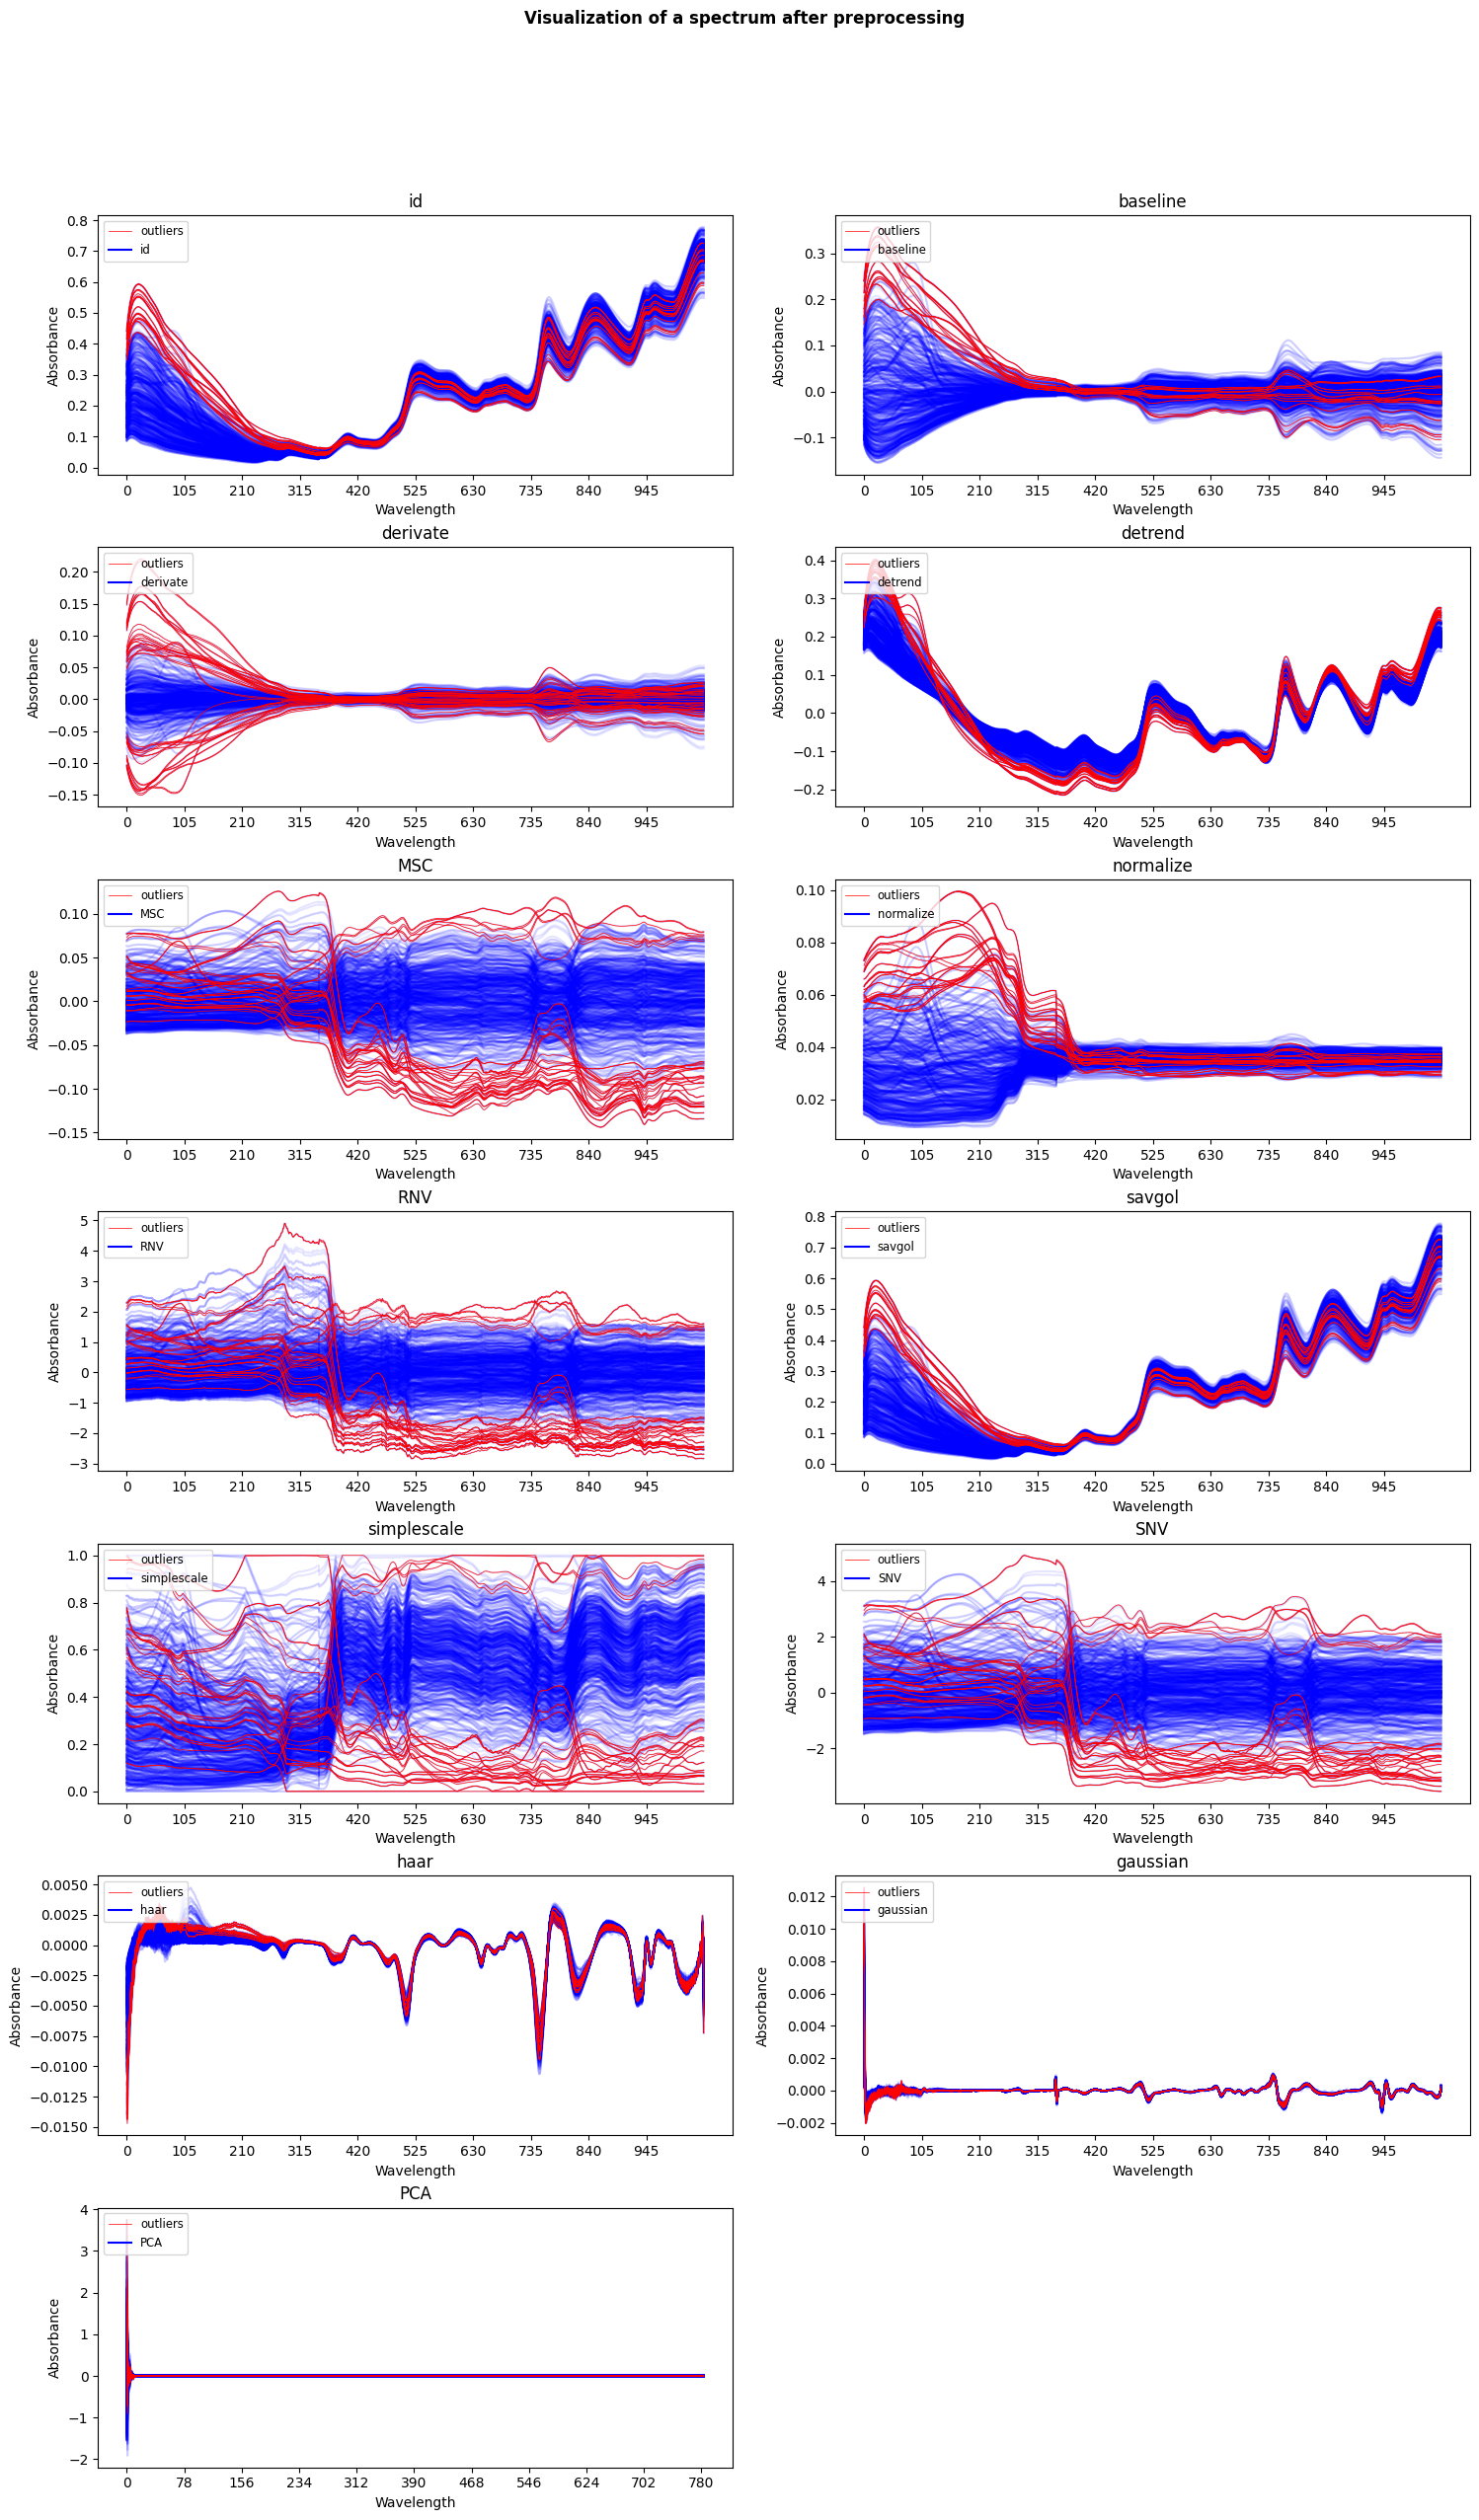

In [31]:
def plot_spectra_outliers(X, names, title='Visualization of the spectra with outliers', save_fig=False):
    if isinstance(X, pd.DataFrame):
        X = [X.values]
    elif isinstance(X, np.ndarray):
            X = [X]

    fig, axs = plt.subplots((len(X)+1)//2, 2, figsize=(15, 4*len(X)//2), dpi=100)
    axs = axs.flatten()
    colors = sns.color_palette("Paired", len(X))
    for i, ax in enumerate(axs):
        if i >= len(X):
            ax.axis('off')
        else:
            name = names[i]
            dataset = X[i]
            if isinstance(dataset, pd.DataFrame):
                 dataset = dataset.values
            outliers = dict_outliers[name]
            ax.set_title(name)
            ax.set_xlabel('Wavelength')
            ax.set_ylabel('Absorbance')
            ax.set_xticks(np.arange(0, dataset.shape[1], dataset.shape[1]//10))
            ax.plot(dataset.T, color='blue', alpha = 0.1)
            
            if len(outliers) > 0:
                ax.plot(dataset[outliers,:].T, color='red', linewidth=0.5)
                ax.plot([], [], color='red', label='outliers', linewidth=0.5)
            
            ax.plot([], [], color='blue', label=name)
            ax.legend(loc='upper left', fontsize='small')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.suptitle(title, fontweight='bold')
    
    # Save figure if required in the folder Figures/outliers_detection
    if save_fig: 
        fig.savefig("Figures/outliers_detection/%s_comp_dissimilarity.png" % data_source, dpi=300)
    plt.show()


# Plot the spectra
plot_spectra_outliers(list(transformed_datasets.values()),
             names = list(transformed_datasets.keys()),
             title = 'Visualization of a spectrum after preprocessing',
             save_fig = True)

### Detection of outliers with Data Depth Theory

In [ ]:
def compute_ED(X):
    median_spectrum = np.median(X, axis=0)
    distances = np.linalg.norm(X - median_spectrum, axis=1)
    return distances

def remove_outliers_DDT_ED(X, kM=2.0):
    distances = compute_ED(X)
    threshold = kM * np.median(distances)
    mask = distances <= threshold
    return X[mask], mask

def identify_mrs(X):
    n_spectra, n_waves = X.shape
    sdiff = np.zeros(n_spectra)
    sequal = np.zeros(n_spectra)

    for j in range(n_spectra):
        for i in range(n_waves):
            l1 = np.sum(X[:, i] > X[j, i])
            l2 = np.sum(X[:, i] == X[j, i])
            l3 = np.sum(X[:, i] < X[j, i])
            sdiff[j] += abs(l1 - l3)
            sequal[j] += l2

    min_sdiff = np.min(sdiff)
    candidates = np.where(sdiff == min_sdiff)[0]
    if len(candidates) > 1:
        max_sequal = sequal[candidates].max()
        mrs_index = candidates[sequal[candidates] == max_sequal][0]
    else:
        mrs_index = candidates[0]
    return mrs_index

# Detection of outliers
spectra_filtered, mask = remove_outliers_DDT_ED(spectra, kM=2.0)

# Select the most representative spectrum
mrs_index = identify_mrs(spectra_filtered)
mrs_spectrum = spectra_filtered[mrs_index]

# Visualization
plt.figure(figsize=(10, 6))
for i, spectrum in enumerate(spectra):
    plt.plot(wavelengths, spectrum, color='gray', alpha=0.5, label='Original' if i == 0 else "")
for i, spectrum in enumerate(spectra_filtered):
    plt.plot(wavelengths, spectrum, color='blue', alpha=0.7)
plt.plot(wavelengths, mrs_spectrum, color='red', linewidth=2, label='MRS')
plt.legend()
plt.title("Spectres + MRS (Data Depth Theory)")
plt.xlabel("Longueur d'onde (nm)")
plt.ylabel("Absorbance")
plt.grid(True)
plt.show()

#### Variant of this first method

In [ ]:
def ddt_ddt_outlier_detection(X):
    NT, nx = X.shape
    non_outlier_mask = np.ones(NT, dtype=bool)

    for j in range(NT):
        above_all = np.all(X[j, :] > X[np.arange(NT) != j], axis=0).all()
        below_all = np.all(X[j, :] < X[np.arange(NT) != j], axis=0).all()
        if above_all or below_all:
            non_outlier_mask[j] = False

    return X[non_outlier_mask], non_outlier_mask

def identify_mrs_ddt(X):
    NT, nx = X.shape
    DIFF = np.zeros((NT, nx))
    EQUAL = np.zeros((NT, nx))

    for j in range(NT):
        for i in range(nx):
            L1 = np.sum(X[:, i] > X[j, i])
            L2 = np.sum(X[:, i] == X[j, i])
            L3 = np.sum(X[:, i] < X[j, i])
            DIFF[j, i] = abs(L1 - L3)
            EQUAL[j, i] = L2

    SDIFF = np.sum(DIFF, axis=1)
    SEQUAL = np.sum(EQUAL, axis=1)

    min_sdiff = np.min(SDIFF)
    candidates = np.where(SDIFF == min_sdiff)[0]
    if len(candidates) > 1:
        max_sequal = np.max(SEQUAL[candidates])
        mrs_index = candidates[SEQUAL[candidates] == max_sequal][0]
    else:
        mrs_index = candidates[0]

    return mrs_index

# Exemple : données spectrales fictives
np.random.seed(0)
wavelengths = np.linspace(200, 750, 221)
spectra = np.random.normal(loc=1.0, scale=0.05, size=(15, len(wavelengths)))
spectra[2] += 0.4  # outlier
spectra[10] -= 0.4  # autre outlier

# Étape 1 : détection d'outliers avec DDT_DDT
spectra_filtered, mask = ddt_ddt_outlier_detection(spectra)

# Étape 2 : identification du MRS
mrs_index = identify_mrs_ddt(spectra_filtered)
mrs_spectrum = spectra_filtered[mrs_index]

# Visualisation
plt.figure(figsize=(10, 6))
for i, spec in enumerate(spectra):
    color = 'gray' if mask[i] else 'black'
    alpha = 0.4 if mask[i] else 0.8
    plt.plot(wavelengths, spec, color=color, alpha=alpha)

plt.plot(wavelengths, mrs_spectrum, color='red', linewidth=2, label="MRS")
plt.title("Détection d'Outliers & MRS (DDT_DDT)")
plt.xlabel("Longueur d'onde (nm)")
plt.ylabel("Absorbance")
plt.legend()
plt.grid(True)
plt.show()
